# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel.

Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

print(df.head())
print(df.columns.tolist())

   Valor_Aluguel  Valor_Condominio  Metragem  N_Quartos  N_banheiros  \
0            480               295        48          2            2   
1            500                 0        50          1            2   
2            500                 0        40          1            2   
3            500                36        45          1            2   
4            500                 0        30          1            1   

   N_Suites  N_Vagas  
0         1        1  
1         1        1  
2         1        1  
3         1        0  
4         0        0  
['Valor_Aluguel', 'Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']


In [4]:
# Ver correlacao com Valor_Aluguel
print(df.corr()['Valor_Aluguel'].sort_values(ascending=False))

Valor_Aluguel       1.000000
Metragem            0.730591
Valor_Condominio    0.695302
N_Vagas             0.652858
N_Suites            0.614397
N_banheiros         0.603715
N_Quartos           0.413139
Name: Valor_Aluguel, dtype: float64


In [6]:
# Etapa 1 — Separar X e Y
X = df[['Metragem']]
y = df['Valor_Aluguel']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nEscolha: Metragem (correlacao 0.73 com Valor_Aluguel)")

X shape: (7203, 1)
y shape: (7203,)

Escolha: Metragem (correlacao 0.73 com Valor_Aluguel)


# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [8]:
# Etapa 2 — Polynomial Features degree=2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

print("Shape apos PolynomialFeatures:", X_poly.shape)

Shape apos PolynomialFeatures: (7203, 3)


# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [10]:
# Etapa 3 — Split e treino
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")
print("Intercepto:", round(modelo.intercept_, 2))
print("Coeficientes:", modelo.coef_.round(2))

Modelo treinado com sucesso!
Intercepto: -632.14
Coeficientes: [ 0.000e+00  4.428e+01 -3.000e-02]


# 4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

R2 (degree=2): 0.5711
RMSE (degree=2): 2155.46


C:\Users\Cliente\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


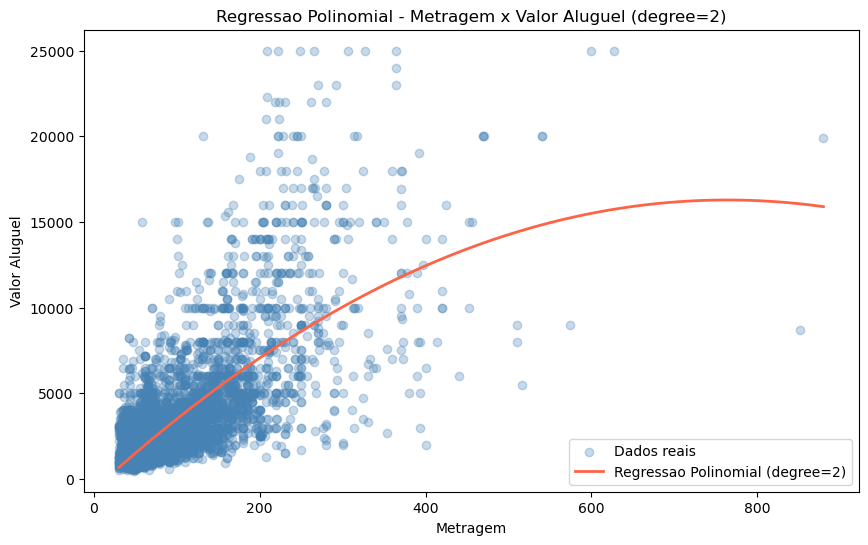

In [13]:
# Previsoes
y_pred = modelo.predict(X_test)

# Metricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 (degree=2): {r2:.4f}")
print(f"RMSE (degree=2): {rmse:.2f}")

# Grafico
X_range = np.linspace(X['Metragem'].min(), X['Metragem'].max(), 300).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = modelo.predict(X_range_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X['Metragem'], y, alpha=0.3, color='steelblue', label='Dados reais')
plt.plot(X_range, y_range_pred, color='tomato', linewidth=2, label='Regressao Polinomial (degree=2)')
plt.xlabel('Metragem')
plt.ylabel('Valor Aluguel')
plt.title('Regressao Polinomial - Metragem x Valor Aluguel (degree=2)')
plt.legend()
plt.show()


### Etapa 4 - Avaliacao degree=2

R2: 0.5711
RMSE: 2155.46

A curva polinomial de grau 2 captura bem a tendencia
de crescimento do aluguel com a metragem nos valores
intermediarios. Porem nos extremos (metragens muito
grandes acima de 600m2) a curva começa a cair, o que
nao faz sentido na realidade. O R2 de 0.57 indica que
o modelo explica 57% da variacao do aluguel apenas
com a metragem, resultado moderado.

# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. Avalie se o resultado desse novo modelo está superior ao anterior.

R2 (degree=4): 0.5585
RMSE (degree=4): 2186.89


C:\Users\Cliente\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


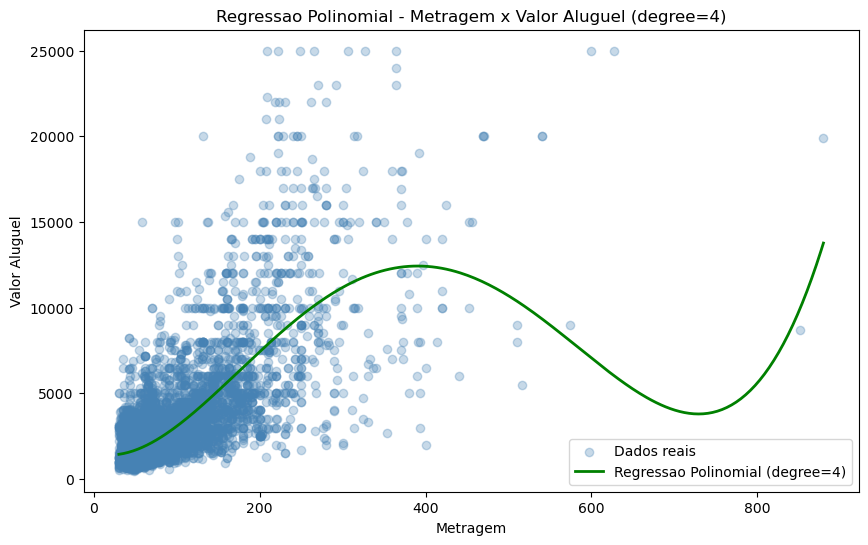


Comparacao:
degree=2: R2=0.5711 | RMSE=2155.46
degree=4: R2=0.5585 | RMSE=2186.89


In [18]:
# Novo modelo com degree=4
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_poly4, y, test_size=0.2, random_state=42)

modelo4 = LinearRegression()
modelo4.fit(X_train4, y_train4)

y_pred4 = modelo4.predict(X_test4)

r2_4 = r2_score(y_test4, y_pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test4, y_pred4))

print(f"R2 (degree=4): {r2_4:.4f}")
print(f"RMSE (degree=4): {rmse_4:.2f}")

# Grafico
X_range_poly4 = poly4.transform(X_range)
y_range_pred4 = modelo4.predict(X_range_poly4)

plt.figure(figsize=(10, 6))
plt.scatter(X['Metragem'], y, alpha=0.3, color='steelblue', label='Dados reais')
plt.plot(X_range, y_range_pred4, color='green', linewidth=2, label='Regressao Polinomial (degree=4)')
plt.xlabel('Metragem')
plt.ylabel('Valor Aluguel')
plt.title('Regressao Polinomial - Metragem x Valor Aluguel (degree=4)')
plt.legend()
plt.show()

# Comparacao
print("\nComparacao:")
print(f"degree=2: R2={r2:.4f} | RMSE={rmse:.2f}")
print(f"degree=4: R2={r2_4:.4f} | RMSE={rmse_4:.2f}")

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.
Minimo: 4 linhas.